# Notebook 05b — H2 Adsorption Energy at All ACAT Sites
## Hastelloy N | Hydrogen Interaction Study

Extends NB05 by placing H2 at all 171 ACAT-identified sites from surface_sites.json instead of 9 hand-picked nominal sites.

Key differences from NB05:
- Site coordinates read from surface_sites.json (NB04b output)
- 171 + 2 jobs submitted as SLURM array (max 8 concurrent)
- H2 intact / dissociated / ambiguous classification before ranking
- Best IS selected from full 171-site landscape

Requires: NB04b completed (surface_sites.json exists)

---
## 1. Theory & Background
---

### 1.1 Adsorption Energy — Formula and Physical Meaning

The adsorption energy quantifies how strongly H₂ binds to the surface compared to being a free molecule in the gas phase [1,2]:

$$E_{\text{ads}} = E(\text{slab} + \text{H}_2) - E(\text{clean slab}) - E(\text{H}_2^{\text{gas}})$$

**Sign convention:**
- $E_{\text{ads}} < 0$ (negative): exothermic adsorption — H₂ **gains** energy by binding to the surface. The more negative, the stronger the binding.
- $E_{\text{ads}} > 0$ (positive): endothermic — H₂ does NOT spontaneously adsorb. This rarely occurs for transition metal surfaces.
- $E_{\text{ads}} = 0$: no interaction between H₂ and surface.

**Physical interpretation:**  
$E_{\text{ads}}$ is the energy released when one H₂ molecule adsorbs from the gas phase onto the surface at the given site. It sets the depth of the potential energy well that H₂ must escape to desorb, and determines the starting geometry for the dissociation barrier calculation in Notebook 06.

**Typical values for Ni-based surfaces [3,4]:**

| Surface | E_ads (eV) | Binding type |
|---------|------------|-------------|
| Physisorption (weak) | −0.01 to −0.1 | van der Waals only |
| Chemisorption (strong) | −0.3 to −1.0 | Covalent/electronic interaction |
| Ni(111) hollow site | ~−0.5 to −0.7 | Chemisorption |

**Key references:** [1–4]

### 1.2 The Four Adsorption Sites on FCC(111)

The FCC(111) surface has four distinct high-symmetry adsorption sites [1,5,6]. These are the only sites that need to be tested — all other positions are equivalent to one of these by symmetry:


| Site | Description | Surface coordination | Subsurface atom? |
|------|-------------|---------------------|------------------|
| **Top (T)** | Directly above a surface atom | 1-fold | None |
| **Bridge (B)** | Between two adjacent surface atoms | 2-fold | None |
| **FCC Hollow (F)** | Above a 3-fold hollow with NO atom below in layer 2 | 3-fold | Layer 3 atom |
| **HCP Hollow (H)** | Above a 3-fold hollow WITH an atom below in layer 2 | 3-fold | Layer 2 atom |

**Why FCC and HCP hollows are different:**  
Both look like 3-fold hollows from above, but differ in what lies beneath. The FCC hollow has an atom in layer 3 directly below (continuing the ABCABC stacking). The HCP hollow has an atom in layer 2 directly below (the site would continue as ABAB if stacking were HCP). This difference in subsurface geometry changes the electronic interaction and adsorption energy [5,6].

**For Hastelloy N:**  
Because our surface contains Mo (one atom), we also test:
- **Top-Ni**: top site above a Ni atom
- **Top-Mo**: top site above the Mo atom

Mo and Ni have significantly different d-band centers, so their top-site adsorption energies will differ noticeably (see Section 1.4).

**Key references:** [1,5,6]

### 1.3 H₂ Placement: Height and Orientation

**Height above surface: 2.5 Å**  
We place the H₂ center of mass 2.5 Å above the top surface layer atom. This is the standard starting distance for H₂ adsorption on transition metal surfaces [3,4,7]. It is:
- Far enough that H₂ is not forced into a pre-dissociated configuration
- Close enough that the MACE potential can compute realistic interaction forces from the first minimization step
- Larger than the Ni-H equilibrium bond length (~1.7 Å) so we avoid artificially constraining the geometry

If placed too close (< 1.5 Å), H₂ may spontaneously dissociate during minimization and we would be computing dissociative adsorption energy rather than molecular adsorption energy. This is relevant for Notebook 06, not here.

**Orientation: parallel to surface (H₂ bond along x-axis)**  
Molecular H₂ approaching a metal surface prefers a flat-lying (parallel) orientation over an upright (perpendicular) orientation for most hollow and bridge sites [3,5,7]. We start all sites with H₂ parallel to the surface. The minimization will rotate H₂ to its true equilibrium orientation.

**H-H bond length: 0.741 Å**  
This is the experimental gas-phase H₂ bond length [8]. We use it as the starting geometry before any relaxation.

**Key references:** [3,4,5,7,8]

### 1.4 The d-Band Model — Why Mo Binds H₂ Differently Than Ni

The d-band model (Hammer-Nørskov) explains why different transition metal atoms on a surface bind adsorbates with different strengths [9,10]. The key insight is:

**The higher the d-band center (ε_d) relative to the Fermi level, the stronger the binding.**

When H₂ approaches a metal surface, its σ and σ* molecular orbitals hybridize with the metal d-band. The interaction has two contributions:
1. **Bonding states** (below Fermi level) — stabilize the adsorbate
2. **Antibonding states** — destabilize if filled (i.e., if they fall below the Fermi level)

A higher d-band center pushes antibonding states above the Fermi level → fewer filled antibonding states → stronger net binding.

**For Hastelloy N surface atoms [9,10,11]:**

| Element | d-band center (ε_d - E_F) | Expected H₂ binding |
|---------|---------------------------|---------------------|
| Mo | −1.3 eV (higher) | **Stronger** |
| Ni | −1.7 eV (lower) | Moderate |
| Cr | −2.0 eV | Weaker |

Therefore: **we expect the top-Mo site to show stronger (more negative) H₂ adsorption than top-Ni**. The hollow sites are generally the most stable due to 3-fold coordination.

**Key references:** [9,10,11]

### 1.5 H₂ Gas Reference Energy

The adsorption energy formula requires E(H₂ gas) — the energy of an isolated H₂ molecule in vacuum. We compute this by:
1. Building a large vacuum box (15 × 15 × 15 Å)
2. Placing one H₂ molecule at the center with bond length 0.741 Å
3. Running CG minimization with the same MACE potential
4. The resulting energy is E(H₂ gas)

**Why not use the experimental H₂ binding energy?**  
We must use MACE-MP-0b2's own prediction for H₂ energy because all three terms in the adsorption energy formula (E_slab+H₂, E_slab, E_H₂) must be computed with the **same potential** at the **same level of theory**. Mixing MACE energies with experimental values introduces systematic errors [1,2].

**Atom type for H:**  
H is type 8 in our system (alphabetical mapping: Al=1, B=2, C=3, Cr=4, Fe=5, Mo=6, Ni=7, H=8). The H₂ gas box uses only H atoms (type 8). The pair_coeff line still lists all 8 elements — same as all other scripts.

**Key references:** [1,2,8]

### 3.1 Imports, Parameters & Load Clean Slab

In [2]:
import numpy as np
import os
import json
import subprocess
import matplotlib.pyplot as plt
from ase.io import read, write
from ase import Atoms
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import ase
print(f'ASE version : {ase.__version__}')
print(f'NumPy       : {np.__version__}')

# ═══════════════════════════════════════════════════════════
# YOUR SYSTEM PATHS
# ═══════════════════════════════════════════════════════════
LAMMPS_CMD  = '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap/lmp'
MACE_MODEL  = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model-mliap_lammps.pt'
KOKKOS_FLAGS = ['-k', 'on', 'g', '1', '-sf', 'kk',
                '-pk', 'kokkos', 'newton', 'on', 'neigh', 'half']
SLURM_CONFIG = {
    'partition'     : 'multigpu',
    'ntasks'        : 1,
    'cpus_per_task' : 8,
    'gpu'           : 'a100:1',
    'time'          : '02:00:00',
    'conda_env'     : 'mace-lammps',
    'cuda_version'  : '12.3.0',
    'openmpi_ver'   : '4.1.6',
    'ld_paths'      : [
        '/shared/EL9/explorer/cuda/12.3.0/lib64/stubs',
        '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap',
        '/home/akinyemi.az/miniforge3/envs/mace-lammps/lib',
    ]
}

# ── Atom type mapping (alphabetical — Notebooks 01-04) ───────
# Type 1=Al, 2=B, 3=C, 4=Cr, 5=Fe, 6=Mo, 7=Ni, 8=H
# H appears as actual atoms for the first time in this notebook
TYPE_MAP  = {1:'Al', 2:'B', 3:'C', 4:'Cr', 5:'Fe', 6:'Mo', 7:'Ni', 8:'H'}
ELEM_STR  = 'Al B C Cr Fe Mo Ni H'
PAIR_STYLE  = 'mliap unified'
PAIR_SUFFIX = '0'

# ── Masses for LAMMPS data files ─────────────────────────────
MASSES = {
    1: (26.9815, 'Al'),
    2: (10.8110, 'B'),
    3: (12.0110, 'C'),
    4: (51.9961, 'Cr'),
    5: (55.8450, 'Fe'),
    6: (95.9600, 'Mo'),
    7: (58.6934, 'Ni'),
    8: ( 1.0080, 'H'),
}

# ── Global type mapping — CRITICAL ───────────────────────────
# Must match pair_coeff * * Al B C Cr Fe Mo Ni H exactly.
# Never use local sorted(set(syms)) mapping — H would get type 1.
E2T = {'Al':1, 'B':2, 'C':3, 'Cr':4, 'Fe':5, 'Mo':6, 'Ni':7, 'H':8}

# ── Adsorption geometry ──────────────────────────────────────
H2_HEIGHT = 2.5    # Å above top surface layer [3,4,7]
H2_BOND   = 0.741  # Å — experimental H-H bond length [8]

# ── Minimization settings (same as NB02, NB04) ───────────────
ETOL    = 0
FTOL    = 1e-6
MAXITER = 10000
MAXEVAL = 100000

# ── File paths ───────────────────────────────────────────────
SLAB_RELAXED = 'structures/notebook04-surface-relaxation/7/hastelloy_7_slab_relaxed.lammps'
H2_GAS_FILE  = 'structures/notebook05-adsorption-energy/7/h2_gas.lammps'

SITES = ['top_ni', 'top_mo', 'top_cr', 'top_fe','top_c', 'top_b','top_al', 'bridge', 'fcc_hollow', 'hcp_hollow']
SITE_LABELS = {
    'top_ni'    : 'Top-Ni',
    'top_mo'    : 'Top-Mo',
    'top_cr'    : 'Top-Cr',
    'top_fe'    : 'Top-Fe',
    'top_c'    : 'Top-C',
    'top_b'    : 'Top-B',
    'top_al'    : 'Top-Al',
    'bridge'    : 'Bridge',
    'fcc_hollow': 'FCC Hollow',
    'hcp_hollow': 'HCP Hollow',
}

# ── Energy references — parsed from logs in cell 3.7 ─────────
# Do NOT hardcode these. All three terms in the adsorption energy
# formula must come from the same minimization protocol [1,2]:
#   E_ads = E(slab+H2) − E(clean_slab) − E(H2_gas)
# E(clean_slab) comes from minimizing hastelloy_n_slab_relaxed.lammps
# with the same script style as the slab+H2 jobs — not from the
# NVT thermo output in Notebook 04. Mixing a thermally-displaced
# NVT snapshot energy with minimized energies introduces a ~2 eV
# systematic error equal to the thermal kinetic energy of the slab.
E_CLEAN_SLAB = None  # set in cell 3.7 from results/ads_clean_slab.log
E_H2_GAS     = None  # set in cell 3.7 from results/ads_h2_gas.log

for d in ['structures/notebook05-adsorption-energy/7', 'results/notebook05-adsorption-energy/7', 'lammps_scripts/notebook05-adsorption-energy/7', 'slurm_scripts/notebook05-adsorption-energy/7']:
    os.makedirs(d, exist_ok=True)

if not os.path.exists(SLAB_RELAXED):
    raise FileNotFoundError(f'{SLAB_RELAXED} not found. Complete Notebook 04 first.')

# Load relaxed slab
slab = read(SLAB_RELAXED, format='lammps-data', style='atomic')
pos  = slab.get_positions()
syms = np.array(slab.get_chemical_symbols())
L    = slab.cell.lengths()

# Top surface layer z-position and H2 placement height
z_surf = pos[:, 2].max()
z_H2   = z_surf + H2_HEIGHT

print(f'Slab loaded        : {len(slab)} atoms')
print(f'Cell               : {L[0]:.4f} × {L[1]:.4f} × {L[2]:.4f} Å')
print(f'Top surface z      : {z_surf:.4f} Å')
print(f'H₂ placement z     : {z_H2:.4f} Å  (z_surf + {H2_HEIGHT} Å) [3,4,7]')
print(f'H₂ bond length     : {H2_BOND} Å  (experimental) [8]')
print(f'Sites to test      : {SITES}')
print(f'pair_coeff         : * * {ELEM_STR}')
print(f'E2T mapping        : {E2T}')
print()
print('Energy references  : parsed from logs in cell 3.7 (not hardcoded)')
print('  E_CLEAN_SLAB     ← results/notebook05-adsorption-energy/7/ads_clean_slab.log')
print('  E_H2_GAS         ← results/notebook05-adsorption-energy/7/ads_h2_gas.log')

# NB05b paths
SURFACE_SITES_JSON = 'results/notebook04b-surface-relaxation/7/surface_sites.json'

for d in [
    'structures/notebook05b-adsorption-energy/7',
    'results/notebook05b-adsorption-energy/7',
    'lammps_scripts/notebook05b-adsorption-energy/7',
    'slurm_scripts/notebook05b-adsorption-energy/7',
]:
    os.makedirs(d, exist_ok=True)

SLAB_RELAXED = 'structures/notebook04-surface-relaxation/7/hastelloy_7_slab_relaxed.lammps'
H2_GAS_FILE  = 'structures/notebook05b-adsorption-energy/7/h2_gas.lammps'

if not os.path.exists(SLAB_RELAXED):
    raise FileNotFoundError(f'{SLAB_RELAXED} not found. Complete NB04 first.')
if not os.path.exists(SURFACE_SITES_JSON):
    raise FileNotFoundError(f'{SURFACE_SITES_JSON} not found. Complete NB04b first.')

slab   = read(SLAB_RELAXED, format='lammps-data', style='atomic')
pos    = slab.get_positions()
syms   = np.array(slab.get_chemical_symbols())
L      = slab.cell.lengths()
z_surf = pos[:, 2].max()
z_H2   = z_surf + H2_HEIGHT

print(f'Slab: {len(slab)} atoms  z_surf={z_surf:.4f} A  z_H2={z_H2:.4f} A')


ASE version : 3.27.0
NumPy       : 2.4.3
Slab loaded        : 360 atoms
Cell               : 12.4479 × 12.9362 × 52.3601 Å
Top surface z      : 38.2290 Å
H₂ placement z     : 40.7290 Å  (z_surf + 2.5 Å) [3,4,7]
H₂ bond length     : 0.741 Å  (experimental) [8]
Sites to test      : ['top_ni', 'top_mo', 'top_cr', 'top_fe', 'top_c', 'top_b', 'top_al', 'bridge', 'fcc_hollow', 'hcp_hollow']
pair_coeff         : * * Al B C Cr Fe Mo Ni H
E2T mapping        : {'Al': 1, 'B': 2, 'C': 3, 'Cr': 4, 'Fe': 5, 'Mo': 6, 'Ni': 7, 'H': 8}

Energy references  : parsed from logs in cell 3.7 (not hardcoded)
  E_CLEAN_SLAB     ← results/notebook05-adsorption-energy/7/ads_clean_slab.log
  E_H2_GAS         ← results/notebook05-adsorption-energy/7/ads_h2_gas.log
Slab: 360 atoms  z_surf=38.2290 A  z_H2=40.7290 A


### 3.2 Load ACAT Sites from surface_sites.json

Replaces NB05 cell 3.2 (manual site coordinate identification).

In [3]:
# Cell 3.2 - Load 171 ACAT sites
with open(SURFACE_SITES_JSON) as f:
    surface_data = json.load(f)

sites_list = surface_data['sites']
print(f'Loaded {len(sites_list)} sites')
print(f'Site types: {surface_data["metadata"]["site_type_counts"]}')

SITE_COORDS = {}
SITE_IDS    = []
for s in sites_list:
    sid  = s['site_id']
    x, y = s['level1']['position'][0], s['level1']['position'][1]
    SITE_COORDS[sid] = (x, y)
    SITE_IDS.append(sid)

print(f'Site IDs: {len(SITE_IDS)} (s_0 to s_{len(SITE_IDS)-1})')
from collections import Counter
comp_counts = Counter(s['level1']['composition'] for s in sites_list)
print('Top 10 compositions:')
for comp, cnt in comp_counts.most_common(10):
    print(f'  {comp:25s}: {cnt}')


Loaded 171 sites
Site types: {'bridge': 87, 'ontop': 29, 'hollow': 55}
Site IDs: 171 (s_0 to s_170)
Top 10 compositions:
  NiNi                     : 49
  NiNiNi                   : 23
  Ni                       : 22
  MoNi                     : 20
  MoNiNi                   : 14
  CrNiNi                   : 6
  CrNi                     : 6
  FeNiNi                   : 4
  BNi                      : 4
  FeNi                     : 4


### 3.3 Build H2 Gas Reference Structure

Same as NB05 cell 3.3.

In [4]:
# ─────────────────────────────────────────────────────────────
# Build H₂ gas reference
# Isolated molecule in large vacuum box
# Same MACE potential — essential for consistent energies [1,2]
# H = type 8 in our type mapping (alphabetical)
# ─────────────────────────────────────────────────────────────

BOX = 15.0   # Å — large enough to avoid periodic image interaction
# H₂ bond along x-axis, centered in box
x0 = BOX/2 - H2_BOND/2
x1 = BOX/2 + H2_BOND/2
y0 = BOX/2
z0 = BOX/2

# Write LAMMPS data file for H₂ gas
with open(H2_GAS_FILE, 'w') as f:
    f.write('# H2 gas reference — written by Notebook 05\n\n')
    f.write('2 atoms\n')
    f.write(f'{len(MASSES)} atom types\n\n')
    f.write(f'0.0  {BOX:.6f}  xlo xhi\n')
    f.write(f'0.0  {BOX:.6f}  ylo yhi\n')
    f.write(f'0.0  {BOX:.6f}  zlo zhi\n\n')
    f.write('Masses\n\n')
    for t, (m, el) in MASSES.items():
        f.write(f'{t}  {m}  # {el}\n')
    f.write('\nAtoms # atomic\n\n')
    # H = type 8
    f.write(f'1  8  {x0:.10f}  {y0:.10f}  {z0:.10f}\n')
    f.write(f'2  8  {x1:.10f}  {y0:.10f}  {z0:.10f}\n')

print(f'Written: {H2_GAS_FILE}')
print(f'  H₂ bond length  : {H2_BOND} Å  (experimental gas phase) [8]')
print(f'  Box size        : {BOX} × {BOX} × {BOX} Å  (vacuum reference)')
print(f'  Atom 1 (H): ({x0:.4f}, {y0:.4f}, {z0:.4f})')
print(f'  Atom 2 (H): ({x1:.4f}, {y0:.4f}, {z0:.4f})')
print(f'  H type          : 8  (alphabetical: Al=1 B=2 C=3 Cr=4 Fe=5 Mo=6 Ni=7 H=8)')

Written: structures/notebook05b-adsorption-energy/7/h2_gas.lammps
  H₂ bond length  : 0.741 Å  (experimental gas phase) [8]
  Box size        : 15.0 × 15.0 × 15.0 Å  (vacuum reference)
  Atom 1 (H): (7.1295, 7.5000, 7.5000)
  Atom 2 (H): (7.8705, 7.5000, 7.5000)
  H type          : 8  (alphabetical: Al=1 B=2 C=3 Cr=4 Fe=5 Mo=6 Ni=7 H=8)


### 3.4 Build Slab+H2 Structures for All 171 ACAT Sites

In [5]:
# Cell 3.4 - Build 171 slab+H2 structures
def build_slab_h2_acat(site_id, x_site, y_site):
    outfile = f'structures/notebook05b-adsorption-energy/7/ads_{site_id}.lammps'
    h1 = np.array([x_site - H2_BOND/2, y_site, z_H2])
    h2 = np.array([x_site + H2_BOND/2, y_site, z_H2])
    h1[0] %= L[0]; h2[0] %= L[0]
    h1[1] %= L[1]; h2[1] %= L[1]
    all_syms = slab.get_chemical_symbols() + ['H', 'H']
    all_pos  = np.vstack([slab.get_positions(), h1, h2])
    with open(outfile, 'w') as f:
        f.write(f'# Hastelloy N slab + H2 at {site_id} - NB05b\n\n')
        f.write(f'{len(all_syms)} atoms\n{len(MASSES)} atom types\n\n')
        f.write(f'0.0  {L[0]:.10f}  xlo xhi\n')
        f.write(f'0.0  {L[1]:.10f}  ylo yhi\n')
        f.write(f'0.0  {L[2]:.10f}  zlo zhi\n\n')
        f.write('Masses\n\n')
        for t, (m, el) in MASSES.items():
            f.write(f'{t}  {m}  # {el}\n')
        f.write('\nAtoms # atomic\n\n')
        for i, (sym, p) in enumerate(zip(all_syms, all_pos), 1):
            f.write(f'{i}  {E2T[sym]}  {p[0]:.10f}  {p[1]:.10f}  {p[2]:.10f}\n')
    return outfile

ads_files = {}
print(f'Building {len(SITE_IDS)} slab+H2 structures...')
for sid in SITE_IDS:
    x, y = SITE_COORDS[sid]
    ads_files[sid] = build_slab_h2_acat(sid, x, y)
print(f'Done. {len(ads_files)} structures written.')


Building 171 slab+H2 structures...
Done. 171 structures written.


### 3.5 Write LAMMPS Minimization Scripts

173 scripts: 171 ACAT sites + clean_slab + h2_gas.

In [6]:
# Cell 3.5 - Write 173 LAMMPS minimization scripts
def write_min_nb05b(job_name, input_file, output_file, boundary='p p f'):
    lines = [
        f'# LAMMPS Minimization - {job_name} - NB05b',
        'units          metal',
        'atom_style     atomic',
        'newton         on',
        f'boundary       {boundary}',
        '',
        f'read_data      {input_file}',
        '',
        f'pair_style     {PAIR_STYLE} {MACE_MODEL} {PAIR_SUFFIX}',
        f'pair_coeff     * * {ELEM_STR}',
        '',
        'neighbor       2.0 bin',
        'neigh_modify   every 1 delay 0 check yes',
        '',
        'thermo         50',
        'thermo_style   custom step pe fmax',
        '',
        f'minimize       {ETOL}  {FTOL}  {MAXITER}  {MAXEVAL}',
        '',
        'variable  pe_final  equal  pe',
        'variable  fmax_f    equal  fmax',
        '',
        'print "ENERGY_RESULTS_START"',
        f'print "  job_name         : {job_name}"',
        'print "  pe_final_eV      : ${pe_final}"',
        'print "  fmax_eV_per_Ang  : ${fmax_f}"',
        'print "ENERGY_RESULTS_END"',
        '',
        f'write_data     {output_file}',
    ]
    path = f'lammps_scripts/notebook05b-adsorption-energy/7/min_{job_name}.lammps'
    with open(path, 'w') as f:
        f.write('\n'.join(lines))
    return path

script_paths = {}
script_paths['clean_slab'] = write_min_nb05b(
    'clean_slab', SLAB_RELAXED,
    'structures/notebook05b-adsorption-energy/7/clean_slab_reminimized.lammps',
    boundary='p p f')
script_paths['h2_gas'] = write_min_nb05b(
    'h2_gas', H2_GAS_FILE,
    'structures/notebook05b-adsorption-energy/7/h2_gas_relaxed.lammps',
    boundary='p p p')
for sid in SITE_IDS:
    script_paths[sid] = write_min_nb05b(
        sid,
        f'structures/notebook05b-adsorption-energy/7/ads_{sid}.lammps',
        f'structures/notebook05b-adsorption-energy/7/ads_{sid}_relaxed.lammps')
print(f'Written {len(script_paths)} LAMMPS scripts.')


Written 173 LAMMPS scripts.


### 3.6 Write and Submit SLURM Array Jobs

--array=0-170%8 runs all 171 site jobs with max 8 concurrent GPUs.
Reference jobs submitted individually.

In [8]:
# Cell 3.6 - Write SLURM array + reference scripts
sc  = SLURM_CONFIG
kk  = ' '.join(KOKKOS_FLAGS)
ld  = '\n'.join('export LD_LIBRARY_PATH=' + p + ':$LD_LIBRARY_PATH'
                  for p in sc['ld_paths'])
cwd = os.getcwd()

# Site index file
index_file = 'slurm_scripts/notebook05b-adsorption-energy/7/site_index.txt'
with open(index_file, 'w') as f:
    f.write('\n'.join(SITE_IDS) + '\n')
print(f'Site index: {index_file}  ({len(SITE_IDS)} entries)')

# Array script lines
arr = ['#!/bin/bash']
arr += [f'#SBATCH --job-name=nb05b_ads']
arr += [f'#SBATCH --ntasks={sc["ntasks"]}']
arr += [f'#SBATCH --cpus-per-task={sc["cpus_per_task"]}']
arr += [f'#SBATCH --gres=gpu:{sc["gpu"]}']
arr += [f'#SBATCH --partition={sc["partition"]}']
arr += [f'#SBATCH --time={sc["time"]}']
arr += ['#SBATCH --array=0-170%8']
arr += ['#SBATCH --output=results/notebook05b-adsorption-energy/7/slurm_%A_%a.out']
arr += ['', f'module load OpenMPI/{sc["openmpi_ver"]}']
arr += [f'module load cuda/{sc["cuda_version"]}']
arr += ['', 'source ~/miniforge3/etc/profile.d/conda.sh']
arr += [f'conda activate {sc["conda_env"]}']
arr += ['', ld, '', f'cd {cwd}', '']
arr += [f'SITE_ID=$(sed -n "$((SLURM_ARRAY_TASK_ID + 1))p" {index_file})']
arr += ['if [ -z "$SITE_ID" ]; then']
arr += ['    echo "ERROR: empty SITE_ID for task $SLURM_ARRAY_TASK_ID"']
arr += ['    exit 1']
arr += ['fi']
arr += ['echo "Task $SLURM_ARRAY_TASK_ID: $SITE_ID"', '']
arr += [f'{LAMMPS_CMD} {kk} \\']
arr += ['    -in lammps_scripts/notebook05b-adsorption-energy/7/min_${SITE_ID}.lammps \\']
arr += ['    -log results/notebook05b-adsorption-energy/7/ads_${SITE_ID}.log', '']
arr += ['if [ $? -ne 0 ]; then']
arr += ['    echo "LAMMPS failed for $SITE_ID"']
arr += ['    exit 1']
arr += ['fi']
arr += ['echo "Done: $SITE_ID $(date)"']

array_path = 'slurm_scripts/notebook05b-adsorption-energy/7/run_array.sh'
with open(array_path, 'w') as f:
    f.write('\n'.join(arr) + '\n')
os.chmod(array_path, 0o755)

# Reference job scripts
for ref_job in ['clean_slab', 'h2_gas']:
    rlines = ['#!/bin/bash']
    rlines += [f'#SBATCH --job-name=nb05b_{ref_job}']
    rlines += [f'#SBATCH --ntasks={sc["ntasks"]}']
    rlines += [f'#SBATCH --cpus-per-task={sc["cpus_per_task"]}']
    rlines += [f'#SBATCH --gres=gpu:{sc["gpu"]}']
    rlines += [f'#SBATCH --partition={sc["partition"]}']
    rlines += [f'#SBATCH --time={sc["time"]}']
    rlines += [f'#SBATCH --output=results/notebook05b-adsorption-energy/7/slurm_{ref_job}_%j.out']
    rlines += ['', f'module load OpenMPI/{sc["openmpi_ver"]}']
    rlines += [f'module load cuda/{sc["cuda_version"]}']
    rlines += ['', 'source ~/miniforge3/etc/profile.d/conda.sh']
    rlines += [f'conda activate {sc["conda_env"]}']
    rlines += ['', ld, '', f'cd {cwd}', '']
    rlines += [f'{LAMMPS_CMD} {kk} \\']
    rlines += [f'    -in {script_paths[ref_job]} \\']
    rlines += [f'    -log results/notebook05b-adsorption-energy/7/ads_{ref_job}.log', '']
    rlines += [f'echo "{ref_job} done: $(date)"']
    ref_path = f'slurm_scripts/notebook05b-adsorption-energy/7/run_{ref_job}.sh'
    with open(ref_path, 'w') as f:
        f.write('\n'.join(rlines) + '\n')
    os.chmod(ref_path, 0o755)

print()
print(f'Files written:')
print(f'  Array script    : {array_path}')
print(f'  Clean slab ref  : slurm_scripts/notebook05b-adsorption-energy/7/run_clean_slab.sh')
print(f'  H2 gas ref      : slurm_scripts/notebook05b-adsorption-energy/7/run_h2_gas.sh')
print()
print('Next step: run auto_submit_nb05b.sh from the project root')
print('  chmod +x auto_submit_nb05b.sh')
print('  nohup bash auto_submit_nb05b.sh > nb05b_submit.log 2>&1 &')
print('  tail -f nb05b_submit.log')
print()
print('After ALL jobs finish, run cell 3.7.')

Site index: slurm_scripts/notebook05b-adsorption-energy/7/site_index.txt  (171 entries)

Files written:
  Array script    : slurm_scripts/notebook05b-adsorption-energy/7/run_array.sh
  Clean slab ref  : slurm_scripts/notebook05b-adsorption-energy/7/run_clean_slab.sh
  H2 gas ref      : slurm_scripts/notebook05b-adsorption-energy/7/run_h2_gas.sh

Next step: run auto_submit_nb05b.sh from the project root
  chmod +x auto_submit_nb05b.sh
  nohup bash auto_submit_nb05b.sh > nb05b_submit.log 2>&1 &
  tail -f nb05b_submit.log

After ALL jobs finish, run cell 3.7.


In [1]:
# 

### 3.7 Parse All Logs and Extract Energies

Run after all SLURM jobs finish.

In [54]:
# Cell 3.7 - Parse all 173 logs
def parse_energy_log(logfile):
    results = {}
    if not os.path.exists(logfile): return None
    with open(logfile) as f:
        for line in f:
            line = line.strip()
            for key in ['pe_final_eV', 'fmax_eV_per_Ang', 'natoms']:
                if key in line and ':' in line:
                    try: results[key] = float(line.split(':')[1].strip())
                    except: pass
    return results if results else None

energies = {}
fmaxes   = {}
missing  = []
all_jobs_b = ['clean_slab', 'h2_gas'] + SITE_IDS

print(f'Parsing {len(all_jobs_b)} logs...')
for job in all_jobs_b:
    log = f'results/notebook05b-adsorption-energy/7/ads_{job}.log'
    res = parse_energy_log(log)
    if res and 'pe_final_eV' in res:
        energies[job] = res['pe_final_eV']
        fmaxes[job]   = res.get('fmax_eV_per_Ang', 0)
    else:
        missing.append(job)

E_CLEAN_SLAB = energies.get('clean_slab')
E_H2_GAS     = energies.get('h2_gas')

print(f'E_CLEAN_SLAB : {E_CLEAN_SLAB:.6f} eV' if E_CLEAN_SLAB else 'E_CLEAN_SLAB: NOT FOUND')
print(f'E_H2_GAS     : {E_H2_GAS:.6f} eV'     if E_H2_GAS     else 'E_H2_GAS: NOT FOUND')
print(f'{len(energies)-2} / {len(SITE_IDS)} site logs parsed.')
if missing:
    print(f'Missing ({len(missing)}): {missing[:5]}{"..." if len(missing)>5 else ""}')
else:
    print('All logs parsed. Run cell 3.8.')


Parsing 173 logs...
E_CLEAN_SLAB : -2390.925227 eV
E_H2_GAS     : -6.790499 eV
168 / 171 site logs parsed.
Missing (3): ['s_0', 's_2', 's_5']


### 3.8 H2 Geometry Audit

- Intact (H-H < 1.2 A): valid IS candidate
- Dissociated (H-H > 2.5 A): spontaneous dissociation
- Ambiguous (1.2 to 2.5 A): flag for inspection

In [55]:
# Cell 3.8 - H2 geometry audit
from ase.io import read as ase_read

intact_sites      = []
dissociated_sites = []
ambiguous_sites   = []
hh_distances      = {}

print('H2 geometry audit')
print('=' * 72)
print(f'  {"Site":10s}  {"H-H (A)":>8s}  {"E_ads (eV)":>12s}  '
      f'{"Label":28s}  {"Status"}')
print('  ' + '-' * 72)

for sid in SITE_IDS:
    rpath = f'structures/notebook05b-adsorption-energy/7/ads_{sid}_relaxed.lammps'
    if not os.path.exists(rpath) or sid not in energies:
        continue
    slab_r = ase_read(rpath, format='lammps-data', atom_style='atomic')
    sym_r  = np.array(slab_r.get_chemical_symbols())
    hpos   = slab_r.get_positions()[sym_r == 'H']
    if len(hpos) != 2: continue
    hh    = float(np.linalg.norm(hpos[0] - hpos[1]))
    hh_distances[sid] = hh
    e_ads = (energies[sid] - E_CLEAN_SLAB - E_H2_GAS
             if E_CLEAN_SLAB and E_H2_GAS else float('nan'))
    label = next((s['level1']['full_label']
                  for s in sites_list if s['site_id'] == sid), '')
    if hh < 1.2:
        status = 'intact'
        intact_sites.append(sid)
    elif hh > 2.5:
        status = 'DISSOCIATED'
        dissociated_sites.append(sid)
    else:
        status = 'ambiguous'
        ambiguous_sites.append(sid)
    flag = '  <-' if status != 'intact' else ''
    print(f'  {sid:10s}  {hh:8.4f}  {e_ads:12.4f}  {label:28s}  {status}{flag}')

print()
print(f'Intact      : {len(intact_sites)} sites  (H-H < 1.2 A)')
print(f'Ambiguous   : {len(ambiguous_sites)} sites  (1.2 <= H-H <= 2.5 A)')
print(f'Dissociated : {len(dissociated_sites)} sites  (H-H > 2.5 A)')
print('Run cell 3.9 to rank and select best IS.')


H2 geometry audit
  Site         H-H (A)    E_ads (eV)  Label                         Status
  ------------------------------------------------------------------------
  s_1           0.7608       -0.1134  Ni_atop                       intact
  s_3           0.7629       -0.1542  FeNiNi_hollow_fcc             intact
  s_4          11.7618       -0.1659  NiNiNi_hollow_fcc             DISSOCIATED  <-
  s_6           0.7608       -0.1134  NiNiNi_hollow_fcc             intact
  s_7           0.7608       -0.1134  NiNiNi_hollow_fcc             intact
  s_8           0.7608       -0.4417  NiNi_bridge                   intact
  s_9           0.7608       -0.4417  NiNi_bridge                   intact
  s_10          0.7629       -0.1542  BNiNi_hollow_fcc              intact
  s_11          0.7607       -0.1659  BNi_bridge                    intact
  s_12          0.7629       -0.4833  BNi_bridge                    intact
  s_13         11.7773       -0.5253  Ni_atop                       DISSO

### 3.9 Compute E_ads and Rank All Sites

Uses intact sites only for IS selection.

In [56]:
# Cell 3.9 - E_ads ranking
if E_CLEAN_SLAB is None or E_H2_GAS is None:
    raise RuntimeError('E_CLEAN_SLAB or E_H2_GAS not set. Run cell 3.7 first.')

e_ads_all    = {}
e_ads_intact = {}
for sid in SITE_IDS:
    if sid not in energies: continue
    e_ads_all[sid] = energies[sid] - E_CLEAN_SLAB - E_H2_GAS
    if sid in intact_sites:
        e_ads_intact[sid] = e_ads_all[sid]

ranked_all    = sorted(e_ads_all,    key=e_ads_all.get)
ranked_intact = sorted(e_ads_intact, key=e_ads_intact.get)

print('Top 20 sites by E_ads:')
print(f'  {"Site":10s}  {"E_ads (eV)":>12s}  {"H-H (A)":>8s}  '
      f'{"Label":30s}  {"Status"}')
print('  ' + '-' * 75)
for sid in ranked_all[:20]:
    hh    = hh_distances.get(sid, 0)
    label = next((s['level1']['full_label']
                  for s in sites_list if s['site_id'] == sid), '')
    stat  = ('intact' if sid in intact_sites else
             'dissoc' if sid in dissociated_sites else 'ambig')
    print(f'  {sid:10s}  {e_ads_all[sid]:12.4f}  {hh:8.4f}  {label:30s}  {stat}')

if ranked_intact:
    best_is    = ranked_intact[0]
    best_label = next((s['level1']['full_label']
                       for s in sites_list if s['site_id'] == best_is), '')
    print(f'\nBest intact IS: {best_is}  ({best_label})')
    print(f'  E_ads : {e_ads_intact[best_is]:.4f} eV')
    print(f'  H-H   : {hh_distances.get(best_is, 0):.4f} A')
else:
    print('WARNING: No intact H2 sites found.')


Top 20 sites by E_ads:
  Site          E_ads (eV)   H-H (A)  Label                           Status
  ---------------------------------------------------------------------------
  s_123            -1.2866    0.7617  NiNi_bridge                     intact
  s_116            -1.1786    0.7666  CrNiNi_hollow_fcc               intact
  s_17             -1.1602    0.7620  FeNi_bridge                     intact
  s_48             -1.1493    0.7593  NiNiNi_hollow_fcc               intact
  s_40             -1.1217    0.7605  NiNi_bridge                     intact
  s_112            -1.1057    0.7612  MoNiNi_hollow_fcc               intact
  s_121            -0.6337   11.9073  NiNi_bridge                     dissoc
  s_125            -0.6080    0.7585  MoNi_bridge                     intact
  s_124            -0.5432    0.7576  MoNiNi_hollow_fcc               intact
  s_91             -0.5266    0.7666  CrNi_bridge                     intact
  s_95             -0.5266   12.4592  NiNi_bridge   

### 3.10 True H2 Site Identification

Runs identify_adsorption_site() on all relaxed structures. Saves H2_site_coords.json.

In [57]:
# Cell 3.10 - True H2 site identification
import sys
sys.path.append('Project2_surface_labeling')
from models.site_identifier import identify_adsorption_site

h2_true_sites = {}
print('H2 true site identification (auto mode)')
print(f'  {"Site":10s}  {"True label":40s}  {"Mode":12s}  {"z_above (A)"}')
print('  ' + '-' * 72)

for sid in SITE_IDS:
    rpath = f'structures/notebook05b-adsorption-energy/7/ads_{sid}_relaxed.lammps'
    if not os.path.exists(rpath): continue
    try:
        result = identify_adsorption_site(rpath, adsorbate='H2', mode='auto')
        s = result[0]
        z  = s.get('z_above_surface', 0.0)
        nn = [{'element': e, 'distance': round(d, 4), 'index': int(i)}
              for e, d, i in s['neighbors']]
        h2_true_sites[sid] = {
            'site_id'        : sid,
            'true_label'     : s['label'],
            'composition'    : s['composition'],
            'mode'           : s['mode'],
            'site_type'      : s['site_type'],
            'z_above_surface': round(z, 4),
            'E_ads_eV'       : round(e_ads_all.get(sid, float('nan')), 6),
            'hh_distance'    : round(hh_distances.get(sid, 0), 4),
            'status'         : ('intact'      if sid in intact_sites else
                                'dissociated' if sid in dissociated_sites
                                else 'ambiguous'),
            'neighbors'      : nn,
        }
        print(f'  {sid:10s}  {s["label"]:40s}  {s["mode"]:12s}  {z:.2f}')
    except Exception as e:
        print(f'  {sid:10s}  ERROR: {e}')

h2_json = 'results/notebook05b-adsorption-energy/7/H2_site_coords.json'
with open(h2_json, 'w') as f:
    json.dump({
        'seed': 7, 'adsorbate': 'H2',
        'n_sites': len(h2_true_sites),
        'best_is': best_is if 'best_is' in dir() else None,
        'sites': h2_true_sites,
    }, f, indent=2)
print(f'Saved: {h2_json}')


H2 true site identification (auto mode)
  Site        True label                                Mode          z_above (A)
  ------------------------------------------------------------------------
  s_0         Ni_atop_physisorbed                       physisorbed   3.13
  s_1         Ni_atop_physisorbed                       physisorbed   3.21
  s_2         Ni_atop_physisorbed                       physisorbed   3.13
  s_3         C_atop_physisorbed                        physisorbed   2.83
  s_4         Ni_atop_physisorbed                       physisorbed   3.13
  s_5         Ni_atop_physisorbed                       physisorbed   3.21
  s_6         Ni_atop_physisorbed                       physisorbed   3.21
  s_7         Ni_atop_physisorbed                       physisorbed   3.21
  s_8         Ni_atop_physisorbed                       physisorbed   3.20
  s_9         Ni_atop_physisorbed                       physisorbed   3.20
  s_10        C_atop_physisorbed                     

### 3.11 Plot Adsorption Energies

Bar chart of E_ads for all intact sites, colored by site type.

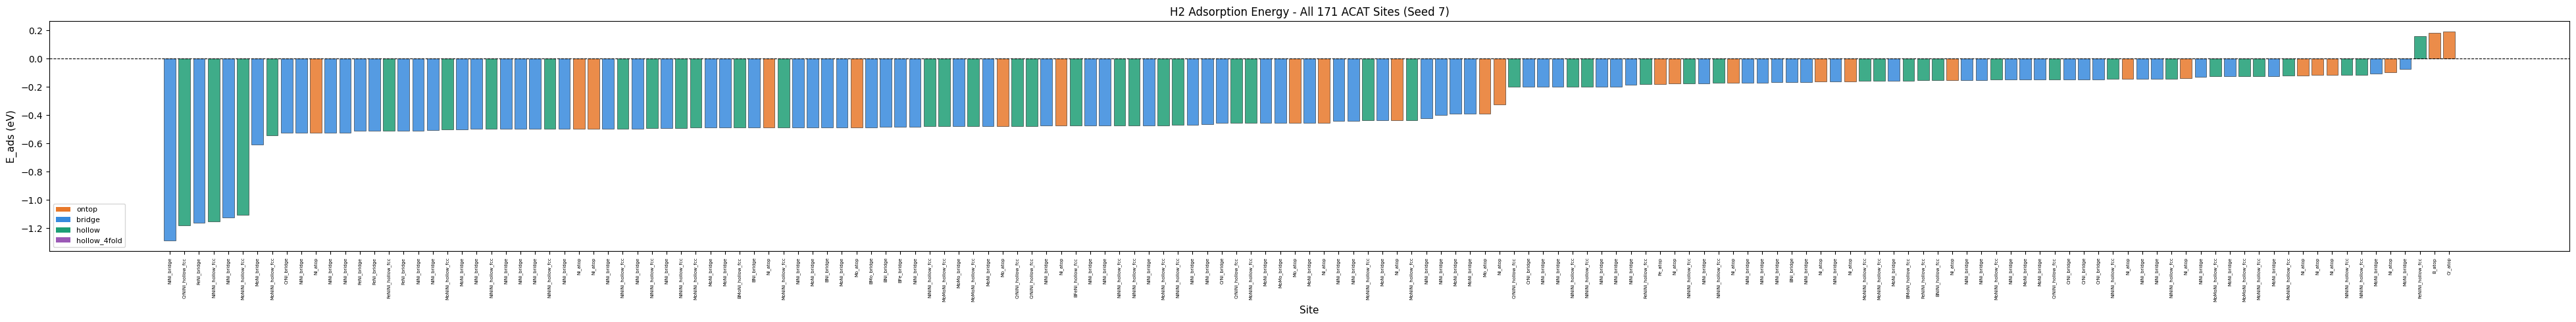

Saved: results/notebook05b-adsorption-energy/7/eads_all_sites.png


In [58]:
# Cell 3.11 - Plot E_ads
if not ranked_intact:
    print('No intact sites to plot.')
else:
    COLOR_MAP = {'ontop': '#E8782A', 'bridge': '#378ADD',
                 'hollow': '#1D9E75', 'hollow_4fold': '#9B59B6'}
    labels_p, eads_p, colors_p = [], [], []
    for sid in ranked_intact:
        s_i = next((s for s in sites_list if s['site_id'] == sid), None)
        if not s_i: continue
        labels_p.append(s_i['level1']['full_label'])
        eads_p.append(e_ads_intact[sid])
        colors_p.append(COLOR_MAP.get(s_i['level1']['site_type'], '#888888'))

    fig, ax = plt.subplots(figsize=(max(12, len(labels_p)*0.25), 5))
    ax.bar(range(len(labels_p)), eads_p, color=colors_p,
           alpha=0.85, edgecolor='black', linewidth=0.4)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xticks(range(len(labels_p)))
    ax.set_xticklabels(labels_p, rotation=90, fontsize=5)
    ax.set_xlabel('Site', fontsize=11)
    ax.set_ylabel('E_ads (eV)', fontsize=11)
    ax.set_title('H2 Adsorption Energy - All 171 ACAT Sites (Seed 7)', fontsize=12)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor=v, label=k)
                       for k, v in COLOR_MAP.items()], fontsize=8)
    plt.tight_layout()
    plt.savefig('results/notebook05b-adsorption-energy/7/eads_all_sites.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/notebook05b-adsorption-energy/7/eads_all_sites.png')


### 3.12 Save Best IS Structure for NB06b

In [59]:
# Cell 3.12 - Save best IS structure
import shutil

if not ranked_intact:
    raise RuntimeError('No intact H2 sites found.')

best_is    = ranked_intact[0]
best_label = next((s['level1']['full_label']
                   for s in sites_list if s['site_id'] == best_is), '')
best_src  = f'structures/notebook05b-adsorption-energy/7/ads_{best_is}_relaxed.lammps'
best_dest = 'structures/notebook05b-adsorption-energy/7/best_adsorption_site.lammps'
shutil.copy(best_src, best_dest)

print(f'Best IS: {best_is}  ({best_label})')
print(f'E_ads   : {e_ads_intact[best_is]:.4f} eV')
print(f'Saved to: {best_dest}')
print('This file is the NEB initial state (IS) for NB06b.')


Best IS: s_123  (NiNi_bridge)
E_ads   : -1.2866 eV
Saved to: structures/notebook05b-adsorption-energy/7/best_adsorption_site.lammps
This file is the NEB initial state (IS) for NB06b.


### 3.13 Decision Cell

All checks must pass before proceeding to NB06b.

In [60]:
# Cell 3.13 - Unified decision cell
print('=' * 62)
print('  NOTEBOOK 05b - FINAL DECISION')
print('=' * 62)

best_exists    = os.path.exists(
    'structures/notebook05b-adsorption-energy/7/best_adsorption_site.lammps')
h2_json_exists = os.path.exists(
    'results/notebook05b-adsorption-energy/7/H2_site_coords.json')
plot_exists    = os.path.exists(
    'results/notebook05b-adsorption-energy/7/eads_all_sites.png')

checks = [
    ('-- Inputs',                         None),
    ('Relaxed slab exists (NB04)',        os.path.exists(SLAB_RELAXED)),
    ('surface_sites.json exists (NB04b)', os.path.exists(SURFACE_SITES_JSON)),
    ('-- Calculations',                   None),
    ('E_CLEAN_SLAB parsed',              E_CLEAN_SLAB is not None),
    ('E_H2_GAS parsed',                  E_H2_GAS is not None),
    (f'{len(intact_sites)} intact H2 sites', len(intact_sites) > 0),
    ('-- Outputs',                        None),
    ('best_adsorption_site.lammps saved', best_exists),
    ('H2_site_coords.json saved',         h2_json_exists),
    ('E_ads plot saved',                  plot_exists),
]

all_pass = True
for label, ok in checks:
    if ok is None:
        print(f'  {label}')
        continue
    status = 'V' if ok else 'X'
    print(f'  {status} {label}')
    if not ok: all_pass = False

print()
if all_pass:
    best_label = next((s['level1']['full_label']
                       for s in sites_list if s['site_id'] == best_is), '')
    print('  ALL CHECKS PASSED')
    print(f'  Proceed to NB06b (single H* - all ACAT sites)')
    print(f'  Best IS: {best_is} ({best_label})')
    print(f'  E_ads  : {e_ads_intact[best_is]:.4f} eV')
    print(f'  File   : structures/notebook05b-adsorption-energy/7/best_adsorption_site.lammps')
else:
    print('  CHECKS FAILED - do NOT proceed to NB06b')
print('=' * 62)


  NOTEBOOK 05b - FINAL DECISION
  -- Inputs
  V Relaxed slab exists (NB04)
  V surface_sites.json exists (NB04b)
  -- Calculations
  V E_CLEAN_SLAB parsed
  V E_H2_GAS parsed
  V 157 intact H2 sites
  -- Outputs
  V best_adsorption_site.lammps saved
  V H2_site_coords.json saved
  V E_ads plot saved

  ALL CHECKS PASSED
  Proceed to NB06b (single H* - all ACAT sites)
  Best IS: s_123 (NiNi_bridge)
  E_ads  : -1.2866 eV
  File   : structures/notebook05b-adsorption-energy/7/best_adsorption_site.lammps
